In [29]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import pandas as pd

results_path = "../experiments/predictive_test_results_coef0.csv"
results_df = pd.read_csv(results_path)


In [31]:
lengths = results_df.sequence_length.unique()
lengths
results_df

,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,0.007449,0.178326,0.185775,3.107743,1.919628e+04,1.919939e+04,5000
1,theta_sweeps,5,0.2625,0.002420,10.343793,10.346213,557.485989,4.031538e+06,4.032096e+06,5000
2,theta_sweeps,5,0.4250,0.006365,2.903771,2.910137,146.669162,4.872917e+05,4.874384e+05,5000
3,theta_sweeps,5,0.5875,0.000592,0.895139,0.895731,40.611168,8.358128e+05,8.358534e+05,5000
4,theta_sweeps,5,0.7500,0.000148,1.254914,1.255062,13.570215,6.308720e+04,6.310077e+04,5000
...,...,...,...,...,...,...,...,...,...,...
220,theta_sweeps,400,3.3500,0.062690,1.045384,1.108074,5.127527,3.507823e+03,3.512951e+03,5000
221,theta_sweeps,400,3.5125,0.066313,0.164889,0.231202,1.289506,1.192141e+03,1.193431e+03,5000
222,theta_sweeps,400,3.6750,0.074515,0.379197,0.453713,1.987256,2.140670e+03,2.142658e+03,5000
223,theta_sweeps,400,3.8375,0.080108,0.565553,0.645661,1.530785,1.497676e+03,1.499206e+03,5000


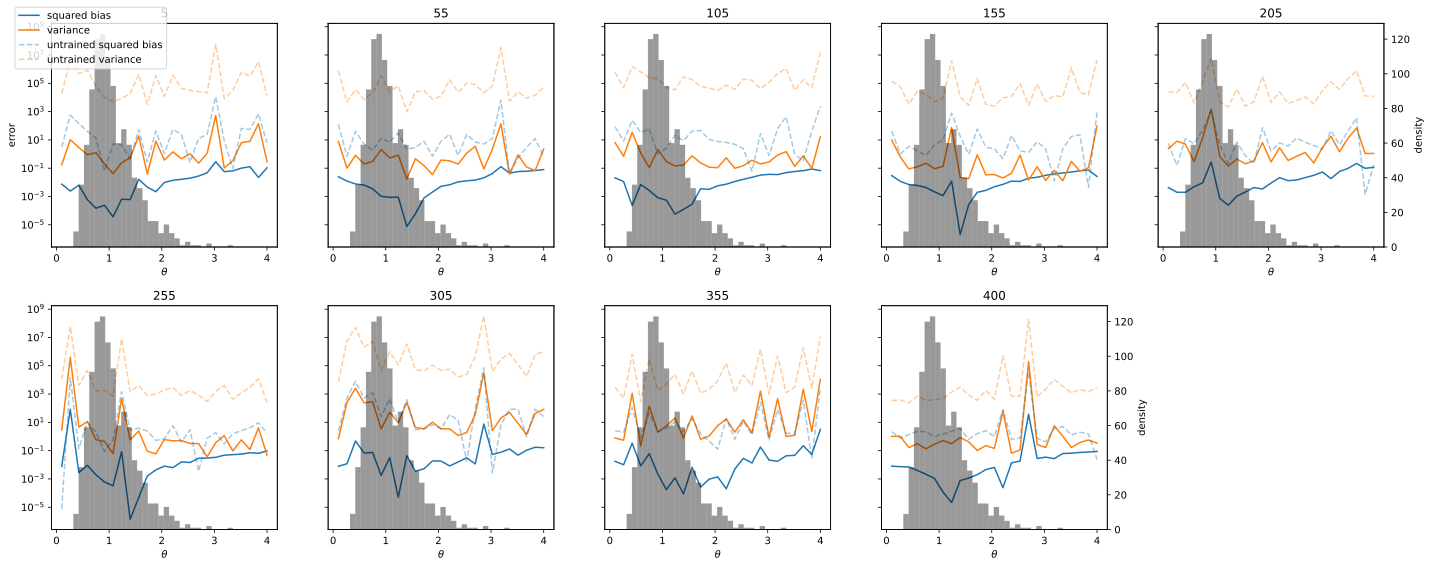

In [32]:
cfg = load_full_config()
data_path = os.path.join('..', cfg['paths']['mgf_data_path'])
data = torch.load(data_path, weights_only=False)
training_thetas = data['theta_values'].numpy()

nrows = 2
ncols = int(np.ceil(len(lengths) / nrows))
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 8), sharey=True)
axs = np.atleast_1d(axs).ravel()

legend_handles, legend_labels = None, None

for i, length in enumerate(lengths):
    ax = axs[i]
    ax.set_title(f"{length}")
    df = results_df[results_df.sequence_length == length]
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    ax.plot(theta, bias, "C0", label="squared bias")
    ax.semilogy(theta, variance, "C1", label="variance")
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_xlabel(r"$\theta$")
    if i == 0:
        ax.set_ylabel("error")
    axt = ax.twinx()
    axt.hist(training_thetas, 30, color="k", alpha=0.4)
    if i % ncols == ncols - 1 or i == len(lengths) - 1:
        axt.set_ylabel("density")
    else:
        axt.set_yticks([])

for j in range(len(lengths), len(axs)):
    axs[j].set_visible(False)

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout(rect=[0, 0, 1, 1])


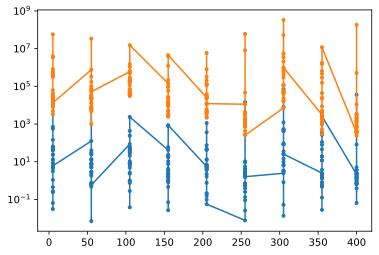

In [33]:
df = results_df[results_df.theta == results_df.theta.unique()[9]]
df = results_df #[results_df.theta == results_df.theta.unique()[9]]
bias = df.trained_squared_bias
variance = df.trained_variance
ut_bias = df.untrained_squared_bias
ut_variance = df.untrained_variance
lengths = df.sequence_length.to_numpy()

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(lengths,  np.abs(bias - ut_bias), "C0.-",label="squared bias")
ax.semilogy(lengths, np.abs(variance - ut_variance), "C1.-",label="variance")

#ax.plot(lengths, ut_bias, "C0+--",label="untrained squared bias")
#ax.semilogy(lengths, ut_variance, "C1+--",label="untrained variance")

In [34]:
# Load variance prediction results (coefficient 1)
variance_results_path = "../experiments/predictive_test_results_coef1.csv"
variance_results_df = pd.read_csv(variance_results_path)

print(f"Variance prediction results shape: {variance_results_df.shape}")
variance_results_df.head()

Variance prediction results shape: (225, 10)


,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,265.689789,0.020686,265.710475,1408.131465,312.699860,1720.831325,5000
1,theta_sweeps,5,0.2625,32.683729,0.006610,32.690339,210.688668,97.218086,307.906754,5000
2,theta_sweeps,5,0.4250,10.416380,0.004045,10.420426,85.492278,48.431393,133.923670,5000
3,theta_sweeps,5,0.5875,4.477084,0.003357,4.480441,46.064575,30.284721,76.349297,5000
4,theta_sweeps,5,0.7500,2.199573,0.002871,2.202444,27.773563,21.579529,49.353092,5000


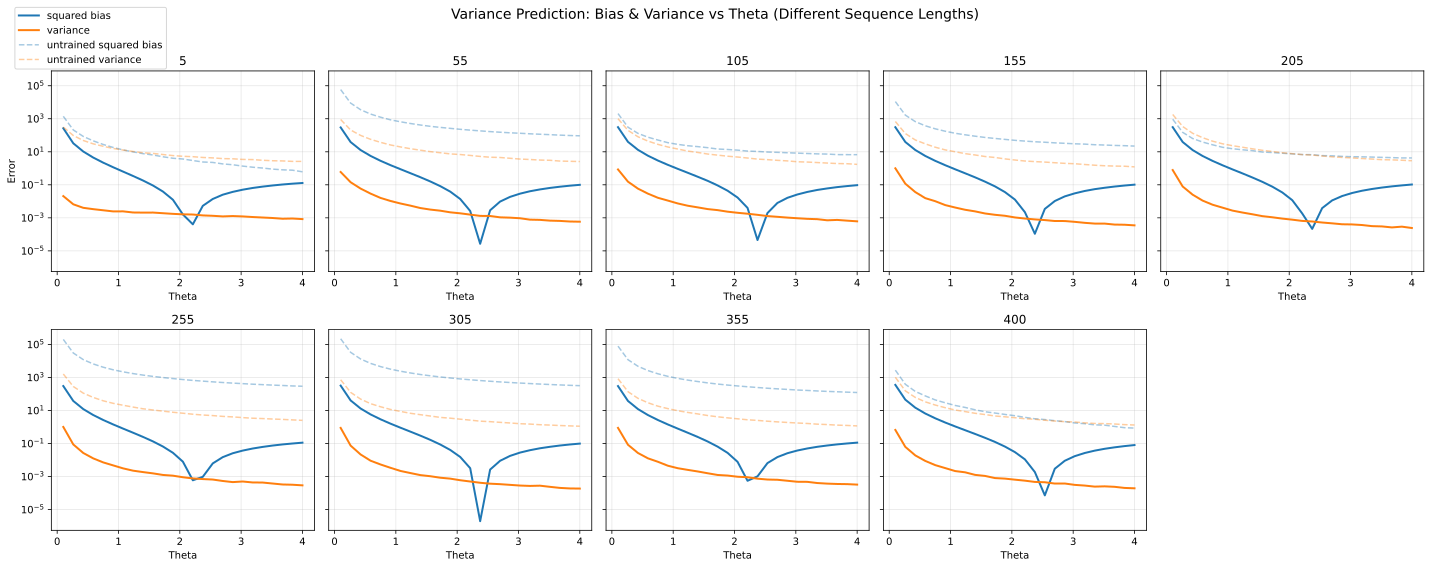

In [35]:
# Plot bias and variance vs theta for different sequence lengths (Variance Prediction)
lengths_var = variance_results_df.sequence_length.unique()

nrows = 2
ncols = int(np.ceil(len(lengths_var) / nrows))
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 8), sharey=True)
axs = np.atleast_1d(axs).ravel()
fig.suptitle("Variance Prediction: Bias & Variance vs Theta (Different Sequence Lengths)", fontsize=14)

legend_handles, legend_labels = None, None

for i, length in enumerate(lengths_var):
    ax = axs[i]
    ax.set_title(f"{length}")
    df = variance_results_df[variance_results_df.sequence_length == length]

    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()

    ax.plot(theta, bias, "C0", label="squared bias", linewidth=2)
    ax.semilogy(theta, variance, "C1", label="variance", linewidth=2)
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_xlabel("Theta")
    if i == 0:
        ax.set_ylabel("Error")
    ax.grid(True, alpha=0.3)

for j in range(len(lengths_var), len(axs)):
    axs[j].set_visible(False)

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
